## Imports

In [1]:
import itertools

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, Patch, Polygon
from scipy.stats import wilcoxon

from analysis_helpers import Episode, Participant
from analysis_helpers.constants import FIG_DIR
from analysis_helpers.functions import rankbiserialr, show_source

## Functions

In [2]:
show_source(rankbiserialr)

In [3]:
def pairwise_precedence(event_matches):
    event_positions = {
        ev.item(): np.flatnonzero(event_matches == ev) 
        for ev in np.unique(event_matches)
    }
    precedence = {}
    for a, b in itertools.combinations(event_positions.keys(), 2):
        a_positions = event_positions[a]
        b_positions = event_positions[b]
        a_prec_count = 0
        for i in a_positions:
            for j in b_positions:
                if i < j:
                    a_prec_count += 1
        precedence[(a, b)] = a_prec_count / (len(a_positions) * len(b_positions))
    return precedence

In [4]:
def order_similarity(precedence_a, precedence_b, shared_events):
    if len(shared_events) < 2:
        raise ValueError('No common event pairs recalled')
    shared_pairs = list(itertools.combinations(sorted(shared_events), 2))
    total = 0
    for a_b in shared_pairs:
        total += abs(precedence_a[a_b] - precedence_b[a_b])
    return 1 - total / len(shared_pairs)

In [5]:
def draw_chain(ax, node_seq, y, label):
    for node_ix in range(1, len(node_seq)):
        ax.annotate('', 
                    xy=(node_ix - 0.30, y), 
                    xytext=(node_ix - 1 + 0.30, y),
                    arrowprops={'arrowstyle': CARTOON_EVENTS_ARROWSTYLE, 
                                'color': CARTOON_EVENTS_ARROWCOLOR, 
                                'lw': 1.3}, 
                    zorder=1)
    for node_ix, node in enumerate(node_seq):
        ax.scatter(node_ix, y, 
                   s=CARTOON_EVENTS_SIZE, 
                   c=CARTOON_EVENTS_COLORS[node], 
                   edgecolors=CARTOON_EVENTS_EDGECOLOR, 
                   linewidths=1.1, 
                   zorder=3)
        ax.text(node_ix, y, 
                CARTOON_EVENT_LABELS[node], 
                ha='center', 
                va='center', 
                fontsize=CARTOON_EVENTS_LABEL_FONTSIZE, 
                fontweight='semibold', 
                zorder=4)
    ax.text(CARTOON_EVENTS_YLABEL_XOFFSET, 
            y, 
            label, 
            ha='right', 
            va='center', 
            fontsize=CARTOON_EVENTS_YLABEL_FONTSIZE, 
            fontweight='semibold')
    return ax

In [6]:
def fade_color_unshared(rgba):
    r, g, b, _ = rgba
    return (1 - NOT_SHARED_ALPHA + NOT_SHARED_ALPHA * r, 
            1 - NOT_SHARED_ALPHA + NOT_SHARED_ALPHA * g, 
            1 - NOT_SHARED_ALPHA + NOT_SHARED_ALPHA * b, 
            1.0)

In [7]:
def textcolor_for_background(bg_rgba):
    r, g, b, _ = bg_rgba
    if (0.299 * r + 0.587 * g + 0.114 * b) > 0.6:
        return 'black'
    return 'white'

In [8]:
def draw_precedence_heatmap(
    ax,
    prec_dict,
    p_events_recalled,
    other_events_recalled,
    n_events_presented,
    outline=False,
    cartoon=False
):
    for row_ix in range(n_events_presented):
        for col_ix in range(row_ix):
            if (
                col_ix not in p_events_recalled or 
                row_ix not in p_events_recalled
            ):
                value = None
                facecolor = NOT_RECALLED_COLOR
                not_shared = False
            elif (
                col_ix not in other_events_recalled or 
                row_ix not in other_events_recalled
            ):
                value = prec_dict[(col_ix, row_ix)]
                facecolor = fade_color_unshared(CMAP(value))
                not_shared = True
            else:
                value = prec_dict[(col_ix, row_ix)]
                facecolor = CMAP(value)
                not_shared = False
                
            cell_rect = Rectangle((col_ix - .5, row_ix - .5), 
                                  1, 1,
                                  facecolor=facecolor, 
                                  edgecolor=facecolor, 
                                  lw=0.1, 
                                  zorder=0)
            ax.add_patch(cell_rect)
            if not_shared:
                hatch_rect = Rectangle((col_ix - .5, row_ix - .5), 
                                       1, 1,
                                       facecolor='none', 
                                       edgecolor=HATCH_COLOR,
                                       hatch='///', 
                                       hatch_linewidth=0.5, 
                                       lw=0, 
                                       zorder=3)
                ax.add_patch(hatch_rect)
                if cartoon:
                    ax.text(col_ix, 
                            row_ix, 
                            '%g' % value,
                            ha='center', 
                            va='center', 
                            color='black', 
                            alpha=NOT_SHARED_ALPHA,
                            fontsize=CARTOON_MATRIX_VALUE_FONTSIZE,
                            fontweight='semibold',
                            zorder=2)

            elif cartoon and value is not None:
                ax.text(col_ix, 
                        row_ix, 
                        '%g' % value,
                        ha='center', 
                        va='center', 
                        color=textcolor_for_background(facecolor),
                        fontsize=CARTOON_MATRIX_VALUE_FONTSIZE,
                        fontweight='semibold',
                        zorder=2)

    if outline:
        verts = [(-0.5, 0.5)]
        for r in range(1, n_events_presented):
            verts.append((r - 0.5, r - 0.5))
            verts.append((r - 0.5, r + 0.5))

        verts.append((-0.5, n_events_presented - 0.5))

        ax.add_patch(Polygon(verts,
                             closed=True,
                             facecolor='none',
                             edgecolor=HEATMAP_OUTLINE_COLOR,
                             lw=HEATMAP_OUTLINE_LINEWIDTH,
                             zorder=5,
                             clip_on=False))

    if cartoon:
        ax.set_xticks(range(n_events_presented - 1))
        ax.set_yticks(range(1, n_events_presented))
        ax.set_xticklabels(CARTOON_EVENT_LABELS[:-1],
                           fontsize=HEATMAP_AXES_TICKLABEL_FONTSIZE)
        ax.set_yticklabels(CARTOON_EVENT_LABELS[1:],
                           fontsize=HEATMAP_AXES_TICKLABEL_FONTSIZE)
    else:
        ticks = list(range(0, n_events_presented, 4))
        ax.set_xticks(ticks)
        ax.set_yticks(ticks[1:])
        ax.set_xticklabels(ticks, fontsize=HEATMAP_AXES_TICKLABEL_FONTSIZE)
        ax.set_yticklabels(ticks[1:], fontsize=HEATMAP_AXES_TICKLABEL_FONTSIZE)
    ax.tick_params(length=0)
    ax.spines[:].set_visible(False)
    ax.set_xlim(-0.5, n_events_presented - 0.5)
    ax.set_ylim(n_events_presented - 0.5, -0.5)
    ax.set_aspect('equal')
    return ax

## Load data

In [9]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

N_BOOTS_CI = 10_000

## Is delayed recall order more similar to own immediate recall order than to others' immediate recall orders?

In [10]:
imm_precs = []
del_precs = []

for p in participants:
    imm_event_matches = p.event_matches['atlep1']
    del_event_matches = p.event_matches['delayed']
    imm_precs.append(pairwise_precedence(imm_event_matches))
    del_precs.append(pairwise_precedence(del_event_matches))
    
order_sims_self = []
order_sims_others = np.empty((len(participants), len(participants) - 1), 
                             dtype=float)

for i, del_prec in enumerate(del_precs):
    p = participants[i]
    del_event_matches = p.event_matches['delayed']
    imm_event_matches = p.event_matches['atlep1']
    shared_events = set(del_event_matches) & set(imm_event_matches)
    sim_self = order_similarity(del_prec, imm_precs[i], shared_events)
    order_sims_self.append(sim_self)
    
    sims_ix = 0
    for j, other_imm_prec in enumerate(imm_precs):
        if j != i:
            other_imm_event_matches = participants[j].event_matches['atlep1']
            shared_events = set(del_event_matches) & set(other_imm_event_matches)
            sim_other = order_similarity(del_prec, imm_precs[j], shared_events)
            order_sims_others[i, sims_ix] = sim_other
            sims_ix += 1
            
pct_ranks = np.empty_like(order_sims_self)
for i, own in enumerate(order_sims_self):
    others = order_sims_others[i]
    pct_ranks[i] = ((own > others).sum() + (own == others).sum() * 0.5) / len(others)
    
T, p = wilcoxon(pct_ranks, 0.5, alternative='two-sided', method='exact')
rb = rankbiserialr(pct_ranks, 0.5)

rank_boot_means = []
rng = np.random.default_rng(0)
for boot in range(N_BOOTS_CI):
    boot_ixs = rng.integers(0, len(pct_ranks), len(pct_ranks))
    rank_boot_means.append(pct_ranks[boot_ixs].mean())
    
rank_mean_ci_low, rank_mean_ci_high = np.percentile(rank_boot_means, (2.5, 97.5))

T, p, rb = T.item(), p.item(), rb.item()
rank_mean_ci_low, rank_mean_ci_high = rank_mean_ci_low.item(), rank_mean_ci_high.item()
print(f'mean own-similarity percentile rank: {pct_ranks.mean():.4f}')
print(f'95% CI = [{rank_mean_ci_low:.3f}, {rank_mean_ci_high:.3f}]')
print(f'{T=}, {p=:.4e}, {rb=:.4f}')

mean own-similarity percentile rank: 0.6393
95% CI = [0.563, 0.710]
T=354.5, p=1.1181e-03, rb=0.5045


## Construct figure

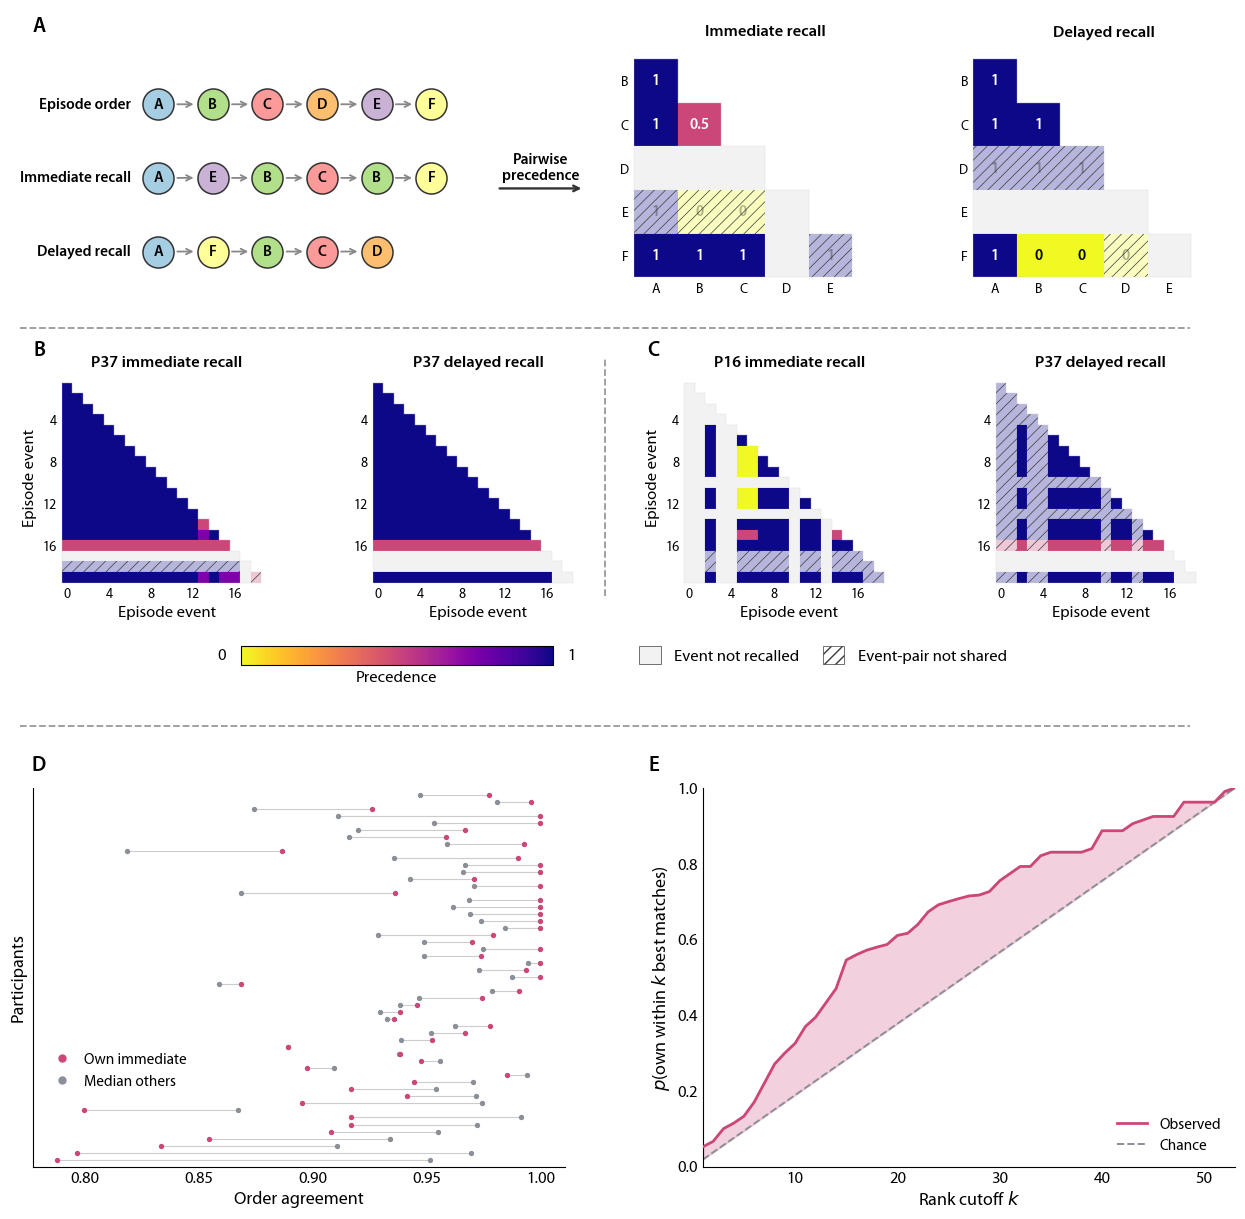

In [11]:
################################ CONFIG ################################

# =============================== SHARED ===============================

CMAP = plt.get_cmap('plasma_r')

AXES_TITLE_FONTSIZE = 12
HEATMAP_AXES_LABEL_FONTSIZE = 12
HEATMAP_AXES_TICKLABEL_FONTSIZE = 10
HEATMAP_OUTLINE_ON = True
HEATMAP_OUTLINE_COLOR = 'lightgrey'
HEATMAP_OUTLINE_LINEWIDTH = 0.2
PANEL_LABEL_FONTSIZE = 15

COLORBAR_LEGEND_FONTSIZE = 12
COLORBAR_VALUE_OFFSET = 0.011

DIVIDER_COLOR = '#999'
DIVIDER_LINEWIDTH = 1.3
HORIZONTAL_DIVIDER_X_INSET = 0.05
VERTICAL_DIVIDER_Y_PAD = 0.01


# ============================== CARTOON ===============================

CARTOON_EVENT_LABELS = ['A', 'B', 'C', 'D', 'E', 'F']
CARTOON_EVENTS_COLORS = {
    0: '#a6cee3', 
    1: '#b2df8a', 
    2: '#fb9a99', 
    3: '#fdbf6f', 
    4: '#cab2d6', 
    5: '#ffff99'
}
CARTOON_EVENTS_SIZE = 500
CARTOON_EVENTS_EDGECOLOR = '#333'
CARTOON_EVENTS_LABEL_FONTSIZE = 11
CARTOON_EVENTS_ARROWCOLOR = '#888'
CARTOON_EVENTS_ARROWSTYLE = '->'
CARTOON_EVENTS_YLABEL_FONTSIZE = 11
CARTOON_EVENTS_YLABEL_XOFFSET = -0.5
CARTOON_EP_EVENTS = [0, 1, 2, 3, 4, 5]
CARTOON_IMM_REC_EVENTS = [0, 4, 1, 2, 1, 5]
CARTOON_DEL_REC_EVENTS = [0, 5, 1, 2, 3]
CARTOON_MATRIX_VALUE_FONTSIZE = 11


# ======================== EXAMPLE PARTICIPANTS ========================

MAIN_PARTICIPANT_N = 37
OTHER_PARTICIPANT_N = 16
NOT_RECALLED_COLOR = '#f2f2f2'
HATCH_COLOR = '#3a3a3a'
NOT_SHARED_ALPHA = 0.30

COLORBAR_HEIGHT = 0.015
COLORBAR_WIDTH = 0.24
COLORBAR_LEGEND_X_INSET = 0.22
COLORBAR_LEGEND_GAP = 0.055
COLORBAR_LEGEND_SHIFT_UP = -0.02


# ============================== RESULTS ===============================

D_E_OBS_COLOR = '#cc4778'
D_E_NULL_COLOR = '#8a8f98'
D_E_LEGEND_FONTSIZE = 11
D_E_AXES_LABEL_FONTSIZE = 13
D_E_AXES_TICKLABEL_FONTSIZE = 12

D_CONNECTOR_ALPHA = 0.45
D_CONNNECTOR_LINEWIDTH = 0.8
D_DOT_SIZE = 8
D_LEGEND_DOT_SIZE = 5

E_FILLBETWEEN_ALPHA = 0.25


########################################################################


# =============================== LAYOUT ===============================

fig = plt.figure(figsize=(13, 13.0))
outer_gridspec = fig.add_gridspec(4, 1, 
                                  height_ratios=[1.3, 1.0, 0.13, 1.8], 
                                  hspace=0.4,
                                  left=0.06, 
                                  right=0.985, 
                                  top=0.94, 
                                  bottom=0.05)
cartoon_gridspec = outer_gridspec[0].subgridspec(1, 3, 
                                                 width_ratios=[2, 1, 1], 
                                                 wspace=0.22)
example_gridspec = outer_gridspec[1].subgridspec(1, 4, wspace=0.16)

results_gridspec = outer_gridspec[3].subgridspec(1, 2, 
                                                 width_ratios=[1.0, 1.0], 
                                                 wspace=0.26)
chains_ax = fig.add_subplot(cartoon_gridspec[0])
cartoon_imm_ax = fig.add_subplot(cartoon_gridspec[1])
cartoon_del_ax = fig.add_subplot(cartoon_gridspec[2])

b_left_ax = fig.add_subplot(example_gridspec[0])
b_right_ax = fig.add_subplot(example_gridspec[1])
c_left_ax = fig.add_subplot(example_gridspec[2])
c_right_ax = fig.add_subplot(example_gridspec[3])

d_ax = fig.add_subplot(results_gridspec[0])
e_ax = fig.add_subplot(results_gridspec[1])


# ============================== CARTOON ===============================

# event chains
draw_chain(chains_ax, CARTOON_EP_EVENTS, y=1.2, label='Episode order')
draw_chain(chains_ax, CARTOON_IMM_REC_EVENTS, y=0.5, label='Immediate recall')
draw_chain(chains_ax, CARTOON_DEL_REC_EVENTS, y=-0.2, label='Delayed recall')
chains_ax.annotate('', 
                   xy=(7.8, 0.4), 
                   xytext=(6.2, 0.4), 
                   arrowprops={'arrowstyle': CARTOON_EVENTS_ARROWSTYLE, 
                               'color': '#333', 
                               'lw': 1.7}, 
                   annotation_clip=False)
chains_ax.text(7, 0.6, 
               'Pairwise\nprecedence', 
               ha='center', 
               va='center', 
               fontsize=CARTOON_EVENTS_YLABEL_FONTSIZE, 
               fontweight='semibold')
chains_ax.set_xlim(-2.3, 7.3)
chains_ax.set_ylim(-0.5, 2.1)
chains_ax.axis('off')

# heatmaps
cartoon_imm_prec = pairwise_precedence(CARTOON_IMM_REC_EVENTS)
cartoon_del_prec = pairwise_precedence(CARTOON_DEL_REC_EVENTS)

draw_precedence_heatmap(cartoon_imm_ax, 
                        cartoon_imm_prec, 
                        p_events_recalled=CARTOON_IMM_REC_EVENTS, 
                        other_events_recalled=CARTOON_DEL_REC_EVENTS, 
                        n_events_presented=len(CARTOON_EP_EVENTS),
                        outline=HEATMAP_OUTLINE_ON,
                        cartoon=True)
cartoon_imm_ax.set_title('Immediate recall', 
                         fontsize=AXES_TITLE_FONTSIZE, 
                         fontweight='semibold', 
                         y=0.9,
                         pad=4)

draw_precedence_heatmap(cartoon_del_ax, 
                        cartoon_del_prec, 
                        p_events_recalled=CARTOON_DEL_REC_EVENTS, 
                        other_events_recalled=CARTOON_IMM_REC_EVENTS, 
                        n_events_presented=len(CARTOON_EP_EVENTS),
                        outline=HEATMAP_OUTLINE_ON,
                        cartoon=True)
cartoon_del_ax.set_title('Delayed recall', 
                         fontsize=AXES_TITLE_FONTSIZE, 
                         fontweight='semibold', 
                         y=0.9,
                         pad=4)


# ======================== EXAMPLE PARTICIPANTS ========================

n_episode_events = len(atlep1.events)
main_p = participants[MAIN_PARTICIPANT_N - 1]
other_p = participants[OTHER_PARTICIPANT_N - 1]

main_p_events_recalled_imm = set(main_p.event_matches['atlep1'])
main_p_events_recalled_del = set(main_p.event_matches['delayed'])
other_p_events_recalled_imm = set(other_p.event_matches['atlep1'])

# panel B
draw_precedence_heatmap(b_left_ax, 
                        imm_precs[MAIN_PARTICIPANT_N - 1], 
                        p_events_recalled=main_p_events_recalled_imm, 
                        other_events_recalled=main_p_events_recalled_del, 
                        n_events_presented=n_episode_events, 
                        outline=HEATMAP_OUTLINE_ON, 
                        cartoon=False)
b_left_ax.set_title(f'P{MAIN_PARTICIPANT_N} immediate recall', 
                    fontsize=AXES_TITLE_FONTSIZE, 
                    fontweight='semibold', 
                    pad=4)
b_left_ax.set_xlabel('Episode event', fontsize=HEATMAP_AXES_LABEL_FONTSIZE)
b_left_ax.set_ylabel('Episode event', fontsize=HEATMAP_AXES_LABEL_FONTSIZE)

draw_precedence_heatmap(b_right_ax, 
                        del_precs[MAIN_PARTICIPANT_N - 1], 
                        p_events_recalled=main_p_events_recalled_del, 
                        other_events_recalled=main_p_events_recalled_imm, 
                        n_events_presented=n_episode_events, 
                        outline=HEATMAP_OUTLINE_ON, 
                        cartoon=False)
b_right_ax.set_title(f'P{MAIN_PARTICIPANT_N} delayed recall', 
                    fontsize=AXES_TITLE_FONTSIZE, 
                    fontweight='semibold', 
                    pad=4)
b_right_ax.set_xlabel('Episode event', fontsize=HEATMAP_AXES_LABEL_FONTSIZE)

# panel C
draw_precedence_heatmap(c_left_ax, 
                        imm_precs[OTHER_PARTICIPANT_N - 1], 
                        p_events_recalled=other_p_events_recalled_imm, 
                        other_events_recalled=main_p_events_recalled_del, 
                        n_events_presented=n_episode_events, 
                        outline=HEATMAP_OUTLINE_ON, 
                        cartoon=False)
c_left_ax.set_title(f'P{OTHER_PARTICIPANT_N} immediate recall', 
                    fontsize=AXES_TITLE_FONTSIZE, 
                    fontweight='semibold', 
                    pad=4)
c_left_ax.set_xlabel('Episode event', fontsize=HEATMAP_AXES_LABEL_FONTSIZE)
c_left_ax.set_ylabel('Episode event', fontsize=HEATMAP_AXES_LABEL_FONTSIZE)

draw_precedence_heatmap(c_right_ax, 
                        del_precs[MAIN_PARTICIPANT_N - 1], 
                        p_events_recalled=main_p_events_recalled_del, 
                        other_events_recalled=other_p_events_recalled_imm, 
                        n_events_presented=n_episode_events, 
                        outline=HEATMAP_OUTLINE_ON, 
                        cartoon=False)
c_right_ax.set_title(f'P{MAIN_PARTICIPANT_N} delayed recall', 
                    fontsize=AXES_TITLE_FONTSIZE, 
                    fontweight='semibold', 
                    pad=4)
c_right_ax.set_xlabel('Episode event', fontsize=HEATMAP_AXES_LABEL_FONTSIZE)


# ============================== RESULTS ===============================

# panel D
med_order_sims_others = np.median(order_sims_others, axis=1)
plot_order = pct_ranks.argsort()

for y_coord, p_ix in enumerate(plot_order):
    sim_self = order_sims_self[p_ix]
    med_others = med_order_sims_others[p_ix]
    d_ax.plot([sim_self, med_others], 
              [y_coord, y_coord], 
              color=D_E_NULL_COLOR, 
              alpha=D_CONNECTOR_ALPHA, 
              lw=D_CONNNECTOR_LINEWIDTH, 
              zorder=1)
    d_ax.scatter(med_others, y_coord, s=D_DOT_SIZE, c=D_E_NULL_COLOR, zorder=2)
    d_ax.scatter(sim_self, y_coord, s=D_DOT_SIZE, c=D_E_OBS_COLOR, zorder=3)

d_ax.set_ylim(-1, len(participants))
d_ax.set_yticks([])
d_ax.set_xlabel('Order agreement', fontsize=D_E_AXES_LABEL_FONTSIZE)
d_ax.set_ylabel('Participants', fontsize=D_E_AXES_LABEL_FONTSIZE)
d_handles = [
    Line2D([], [], 
           marker='o', 
           color=D_E_OBS_COLOR, 
           linestyle='None', 
           markersize=D_LEGEND_DOT_SIZE, 
           label='Own immediate'), 
    Line2D([], [], 
           marker='o', 
           color=D_E_NULL_COLOR, 
           linestyle='None', 
           markersize=D_LEGEND_DOT_SIZE, 
           label='Median others')
]
d_ax.legend(handles=d_handles, 
            loc='lower left', 
            bbox_to_anchor=(0, 0.17), 
            fontsize=D_E_LEGEND_FONTSIZE, 
            frameon=False, 
            handletextpad=0.5, 
            labelspacing=0.5)
d_ax.spines[['top', 'right']].set_visible(False)

# panel E
ks = np.arange(1, len(participants) + 1)
chance = ks / len(participants)
below = np.array([
    (order_sims_self[i] < order_sims_others[i]).sum() 
    for i in range(len(participants))
])
ties = np.array([
    (order_sims_self[i] == order_sims_others[i]).sum() 
    for i in range(len(participants))
])
survival_rate = np.array([
    np.mean(np.clip(k - below, 0, ties + 1) / (ties + 1)) 
    for k in ks
])

e_ax.plot(ks, 
          survival_rate, 
          color=D_E_OBS_COLOR, 
          lw=2, 
          zorder=3, 
          label='Observed')
e_ax.plot(ks, 
          chance, 
          color=D_E_NULL_COLOR, 
          ls='--', 
          lw=1.4, 
          zorder=2, 
          label='Chance')
e_ax.fill_between(ks, 
                  chance, 
                  survival_rate, 
                  color=D_E_OBS_COLOR, 
                  alpha=E_FILLBETWEEN_ALPHA, 
                  zorder=1)
e_ax.set_xlim(1, len(participants))
e_ax.set_ylim(0, 1)
e_ax.set_xlabel('Rank cutoff $k$', fontsize=D_E_AXES_LABEL_FONTSIZE)
e_ax.set_ylabel('$p$(own within $k$ best matches)', 
                fontsize=D_E_AXES_LABEL_FONTSIZE)
e_ax.legend(loc='lower right', fontsize=D_E_LEGEND_FONTSIZE, frameon=False)
e_ax.spines[['top', 'right']].set_visible(False)

for ax in (d_ax, e_ax):
    ax.tick_params(axis='both', length=0, labelsize=D_E_AXES_TICKLABEL_FONTSIZE)


####################### SHARED COLORBAR & LEGEND #######################

fig.canvas.draw()

# colorbar
cbar_position = outer_gridspec[2].get_position(fig)
cbar_y = cbar_position.y1 - COLORBAR_HEIGHT / 2 - COLORBAR_LEGEND_SHIFT_UP
cbar_ax = fig.add_axes([COLORBAR_LEGEND_X_INSET, 
                        cbar_y - COLORBAR_HEIGHT / 2, 
                        COLORBAR_WIDTH, 
                        COLORBAR_HEIGHT])
cbar = fig.colorbar(ScalarMappable(norm=mcolors.Normalize(0, 1), cmap=CMAP), 
                    cax=cbar_ax, 
                    orientation='horizontal')
cbar.set_ticks([])
cbar.set_label('Precedence', fontsize=COLORBAR_LEGEND_FONTSIZE)
fig.text(COLORBAR_LEGEND_X_INSET - COLORBAR_VALUE_OFFSET, cbar_y, 
         '0', 
         ha='right', 
         va='center', 
         fontsize=COLORBAR_LEGEND_FONTSIZE)
fig.text(COLORBAR_LEGEND_X_INSET + COLORBAR_WIDTH + COLORBAR_VALUE_OFFSET, 
         cbar_y, 
         '1', 
         ha='left', 
         va='center', 
         fontsize=COLORBAR_LEGEND_FONTSIZE)

# legend
legend_handles = [
    Patch(facecolor=NOT_RECALLED_COLOR, 
          edgecolor=HATCH_COLOR, 
          linewidth=0.5, 
          label='Event not recalled'), 
    Patch(facecolor='white', 
          edgecolor=HATCH_COLOR, 
          linewidth=0.5, 
          hatch='///', 
          hatch_linewidth=0.5, 
          label='Event-pair not shared')
]
fig.legend(handles=legend_handles, 
           loc='center left', 
           bbox_to_anchor=(COLORBAR_LEGEND_X_INSET + COLORBAR_WIDTH + COLORBAR_LEGEND_GAP, cbar_y),
           fontsize=COLORBAR_LEGEND_FONTSIZE,
           frameon=False,
           handlelength=1.3, 
           handleheight=1.3, 
           ncol=2, 
           columnspacing=1.4)


############################ DIVIDER LINES #############################

cartoon_row_axes = (chains_ax, cartoon_imm_ax, cartoon_del_ax)
example_row_axes = (b_left_ax, b_right_ax, c_left_ax, c_right_ax)
results_row_axes = (e_ax, d_ax)

cartoon_row_bottom = min(ax.get_position().y0 for ax in cartoon_row_axes)
example_row_top = max(ax.get_position().y1 for ax in example_row_axes)
cartoon_example_divider_y = (cartoon_row_bottom + example_row_top) / 2
fig.add_artist(Line2D([HORIZONTAL_DIVIDER_X_INSET, 1 - HORIZONTAL_DIVIDER_X_INSET], 
                      [cartoon_example_divider_y, cartoon_example_divider_y], 
                      color=DIVIDER_COLOR,
                      ls='--',
                      lw=DIVIDER_LINEWIDTH))

b_c_divider_x = 0.5
b_c_divider_y_bottom = min(ax.get_position().y0 for ax in example_row_axes)
b_c_divider_y_top = max(ax.get_position().y1 for ax in example_row_axes)
fig.add_artist(Line2D([b_c_divider_x, b_c_divider_x], 
                      [b_c_divider_y_bottom - VERTICAL_DIVIDER_Y_PAD, 
                       b_c_divider_y_top + VERTICAL_DIVIDER_Y_PAD], 
                      color=DIVIDER_COLOR,
                      ls='--',
                      lw=DIVIDER_LINEWIDTH))

cbar_row_bottom = cbar_ax.get_position().y0
results_row_top = max(ax.get_position().y1 for ax in results_row_axes)
example_results_divider_y = (cbar_row_bottom + results_row_top) / 2
fig.add_artist(Line2D([HORIZONTAL_DIVIDER_X_INSET, 1 - HORIZONTAL_DIVIDER_X_INSET], 
                      [example_results_divider_y, example_results_divider_y], 
                      color=DIVIDER_COLOR, 
                      ls='--', 
                      lw=DIVIDER_LINEWIDTH))

############################# PANEL LABELS #############################

fig.text(0.07, 
         chains_ax.get_position().y1 - 0.02, 
         'A', 
         fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='semibold', 
         ha='right', 
         va='bottom')
fig.text(0.07, 
         b_left_ax.get_position().y1 + 0.01, 
         'B', 
         fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='semibold', 
         ha='right', 
         va='bottom')

fig.text(0.542, 
         c_left_ax.get_position().y1 + 0.01, 
         'C', 
         fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='semibold', 
         ha='right', 
         va='bottom')

fig.text(0.07, 
         d_ax.get_position().y1 + 0.01, 
         'D', 
         fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='semibold', 
         ha='right', 
         va='bottom')

fig.text(0.542, 
         e_ax.get_position().y1 + 0.01, 
         'E', 
         fontsize=PANEL_LABEL_FONTSIZE, 
         fontweight='semibold', 
         ha='right', 
         va='bottom')

# plt.savefig(FIG_DIR / 'order-similarity.pdf', bbox_inches='tight')

plt.show()